In [168]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
import scipy as sc
import scipy.stats as stats
from scipy.signal import find_peaks
from statsmodels.stats.anova import AnovaRM

sys.path.append('/Users/kjesta/Desktop/LABDATA/Kjersti_100226/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *
from open_data import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [169]:
data = processed_data_20cm

In [170]:
freqs = list(data.keys())
volts = [0.1, 0.2, 0.25, 0.3]
cond = ["None", 'p005']

def perform_AnovaRM(freq, cond):
    if freq in [1.1, 1.2, 1.3, 1.4, 1.5]:
        volts = [0.1, 0.2, 0.3]
    else:
        volts = [0.1, 0.2, 0.25, 0.3]

    results = []
    for v in volts:
        for r in ["R1", "R2", "R3"]:
            df = data[freq][v][cond][r]

            # Extracting free surface elevation data
            eta_P0 = df['P_0'].dropna().values * -1
            eta_P3 = df['P_3'].dropna().values * -1

            # Detect peaks in the free surface elevation data
            threshold = np.sqrt(2)*np.std(eta_P0) - 0.001
            peak_idx_P0 = find_peaks(eta_P0, threshold)[0]
            peak_idx_P3 = find_peaks(eta_P3, threshold)[0]

            # Keep positive amplitudes only
            amp_P0 = []
            for idx in peak_idx_P0:
                amp_P0.append(eta_P0[idx])
            amp_P3 = []
            for idx in peak_idx_P3:
                amp_P3.append(eta_P3[idx])

            amp_P0 = [amp for amp in amp_P0 if amp > 0]
            amp_P3 = [amp for amp in amp_P3 if amp > 0]
            print(f"Number of peaks for P_0: {len(amp_P0)}, Number of peaks for P_3: {len(amp_P3)}")
            # Need same number of peaks for both conditions to perform ANOVA
            n = min(len(amp_P0), len(amp_P3))
            amp_P0 = amp_P0[:n]
            amp_P3 = amp_P3[:n]

            print(n)

            subjects = np.arange(1, n + 1)

            df_long = pd.DataFrame({
            'subject': np.concatenate([subjects, subjects]),
            'probe':   np.concatenate([np.repeat('P_0', n), np.repeat('P_3', n)]),
            'amplitude': np.concatenate([amp_P0, amp_P3])})

            print(f"ANOVA for freq={freq} Hz, voltage={v} V, condition={cond}, run={r}:")

            aov = AnovaRM(
                data=df_long,
                depvar='amplitude',
                subject='subject',
                within=['probe']
            ).fit()

            print(aov.summary())  

            results.append({
                'freq': freq,
                'voltage': v,
                'condition': cond,
                'run': r,
                'anova_table': aov.anova_table
            })
            if cond == 'p005':
                config = '5 cm plates'
            else:
                config = 'no plates'
            """ plt.hist(amp_P0, bins=10, alpha=0.5, color='C0', label='P_0')
            plt.vlines(np.mean(amp_P0), ymin=0, ymax=plt.gca().get_ylim()[1], colors='C0', linestyles='dashed', label='Mean P_0')
            plt.hist(amp_P3, bins=10,alpha=0.5, color='C1', label='P_3')
            plt.vlines(np.mean(amp_P3), ymin=0, ymax=plt.gca().get_ylim()[1], colors='C1', linestyles='dashed', label='Mean P_3')
            plt.xlabel('Amplitude (m)')
            plt.ylabel('Frequency')
            plt.title(f'Distribution of Free Surface Amplitudes \n f={freq} Hz, V={v} V, {config}, {r}')
            plt.legend(title =f'p-value={aov.anova_table.loc["probe", "Pr > F"]:.3f}', ncol=2)
            plt.show() """

    return results, amp_P0, amp_P3   

In [171]:
anova_f11, amp_P0, amp_P3 = perform_AnovaRM(1.5, "None")

Number of peaks for P_0: 259, Number of peaks for P_3: 108
108
ANOVA for freq=1.5 Hz, voltage=0.1 V, condition=None, run=R1:
               Anova
      F Value Num DF  Den DF  Pr > F
------------------------------------
probe 11.9617 1.0000 107.0000 0.0008

Number of peaks for P_0: 280, Number of peaks for P_3: 114
114
ANOVA for freq=1.5 Hz, voltage=0.1 V, condition=None, run=R2:
               Anova
      F Value Num DF  Den DF  Pr > F
------------------------------------
probe 28.3579 1.0000 113.0000 0.0000

Number of peaks for P_0: 253, Number of peaks for P_3: 106
106
ANOVA for freq=1.5 Hz, voltage=0.1 V, condition=None, run=R3:
               Anova
      F Value Num DF  Den DF  Pr > F
------------------------------------
probe 11.2440 1.0000 105.0000 0.0011

Number of peaks for P_0: 111, Number of peaks for P_3: 78
78
ANOVA for freq=1.5 Hz, voltage=0.2 V, condition=None, run=R1:
               Anova
      F Value Num DF  Den DF Pr > F
-----------------------------------
probe 78.2

In [172]:
import statsmodels.formula.api as smf

In [173]:
def mixed_model(freq, cond):
    if freq in [1.1, 1.2, 1.3, 1.4, 1.5]:
        volts = [0.1, 0.2, 0.3]
    else:
        volts = [0.1, 0.2, 0.25, 0.3]

    all_results = {}

    for v in volts:
        for r in ["R1", "R2", "R3"]:
            df = data[freq][v][cond][r]

            # Keep time alignment; do NOT dropna separately
            eta_P0 = df['P_0'].values * -1
            eta_P3 = df['P_3'].values * -1  # includes NaNs where discarded

            # Detect peaks
            threshold = np.sqrt(2) * np.nanstd(eta_P0) - 0.001
            peak_idx_P0 = find_peaks(eta_P0, threshold, distance=90)[0]
            peak_idx_P3 = find_peaks(eta_P3, threshold, distance=90)[0]

            # Indices where P_3 has data
            p3_indices = np.where(~np.isnan(eta_P3))[0]

            p3_start = p3_indices[0]
            p3_end   = p3_indices[-1]

            # Keep only P_0 peaks that lie inside the valid time window for P_3
            peak_idx_P0 = [i for i in peak_idx_P0 if (i >= p3_start) and (i <= p3_end)]


            # Get amplitudes
            amp_P0 = eta_P0[peak_idx_P0]
            amp_P3 = eta_P3[peak_idx_P3]

            # Make same length by truncating to min length
            n = min(len(amp_P0), len(amp_P3))
            amp_P0 = amp_P0[:n]
            amp_P3 = amp_P3[:n]

            mask_pos = (amp_P0 > 0) & (amp_P3 > 0)
            amp_P0 = amp_P0[mask_pos]
            amp_P3 = amp_P3[mask_pos]

            print(f"freq={freq}, V={v}, run={r}: number of paired peaks = {n}")

            subjects = np.arange(1, n + 1)

            df_long = pd.DataFrame({
                'subject':   np.concatenate([subjects, subjects]),
                'probe':     np.concatenate([np.repeat('P_0', n), np.repeat('P_3', n)]),
                'amplitude': np.concatenate([amp_P0, amp_P3]),
                'freq':      freq,
                'voltage':   v,
                'run':       r,
                'cond':      cond,
            })

            # Sanity check: do we have both probe levels?
            if df_long['probe'].nunique() < 2:
                print("  Only one probe level present after filtering; skipping.")
                continue

            print(f"Mixed model for freq={freq} Hz, voltage={v} V, condition={cond}, run={r}:")

            model = smf.mixedlm("amplitude ~ probe", data=df_long, groups=df_long["subject"])
            result = model.fit()
            #print(result.summary())
            plt.plot(eta_P0, label='P_0')
            plt.plot(eta_P3, label='P_3')
            plt.plot(peak_idx_P0, eta_P0[peak_idx_P0], label='P_0 peaks', marker='x', linestyle='None')
            plt.plot(peak_idx_P3, eta_P3[peak_idx_P3], label='P_3 peaks', marker='x', linestyle='None')
            plt.xlabel('Time')
            plt.ylabel('Amplitude')
            plt.legend()
            plt.show()

            all_results[(freq, v, cond, r)] = result

    return all_results


In [174]:
def mixed_model(freq, cond):
    """
    Perform mixed model analysis for given frequency and condition.
    Gives an estimate on whether the probe level (P_0 vs P_3) has a significant effect on the amplitude
    of the free surface elevation peaks, while accounting for variability across runs.
    """
    if freq in [1.1, 1.2, 1.3, 1.4, 1.5]:
        volts = [0.1, 0.2, 0.3]
    else:
        volts = [0.1, 0.2, 0.25, 0.3]

    all_results = {}

    for v in volts:
        rows = []  # hold data from all runs for this voltage

        for r in ["R1", "R2", "R3"]:
            df = data[freq][v][cond][r]

            # Keep time alignment
            eta_P0 = df['P_0'].values * -1
            eta_P3 = df['P_3'].values * -1  # includes NaNs

            # Detect peaks
            threshold = np.sqrt(2) * np.nanstd(eta_P0) - 0.001
            peak_idx_P0 = find_peaks(eta_P0, np.sqrt(2) * np.nanstd(eta_P0) - 0.001, distance=90)[0]
            peak_idx_P3 = find_peaks(eta_P3, np.sqrt(2) * np.nanstd(eta_P3) - 0.001, distance=90)[0]

            # Indices where P_3 has data
            p3_indices = np.where(~np.isnan(eta_P3))[0]

            p3_start = p3_indices[0]
            p3_end   = p3_indices[-1]

            # Keep only P_0 peaks that lie inside the valid time window for P_3
            peak_idx_P0 = [i for i in peak_idx_P0 if (i >= p3_start) and (i <= p3_end)]

            # Get amplitudes
            amp_P0 = eta_P0[peak_idx_P0]
            amp_P3 = eta_P3[peak_idx_P3]

            # Make same length by truncating to min length
            n = min(len(amp_P0), len(amp_P3))
            amp_P0 = amp_P0[:n]
            amp_P3 = amp_P3[:n]

            # Keep only positive amplitudes
            mask_pos = (amp_P0 > 0) & (amp_P3 > 0)
            amp_P0 = amp_P0[mask_pos]
            amp_P3 = amp_P3[mask_pos]
            n = len(amp_P0)

            print(f"freq={freq}, V={v}, run={r}: paired peaks (after filtering) = {n}")

            peak_id = np.arange(n)

            df_long = pd.DataFrame({
                'peak_id':   np.concatenate([peak_id, peak_id]),
                'probe':     np.concatenate([np.repeat('P_0', n),
                                             np.repeat('P_3', n)]),
                'amplitude': np.concatenate([amp_P0, amp_P3]),
                'freq':      freq,
                'voltage':   v,
                'run':       r,
                'cond':      cond,
            })
            rows.append(df_long)

            """ # Plot to visually check the peaks detected
            plt.figure()
            plt.plot(eta_P0, label='P_0')
            plt.plot(eta_P3, label='P_3')
            plt.plot(peak_idx_P0, eta_P0[peak_idx_P0], 'x', label='P_0 peaks', linestyle='None')
            plt.plot(peak_idx_P3, eta_P3[peak_idx_P3], 'x', label='P_3 peaks', linestyle='None')
            plt.xlabel('Time index')
            plt.ylabel('Amplitude')
            plt.title(f"freq={freq}, V={v}, run={r}")
            plt.legend()
            plt.show()
 """
        # After looping over runs: fit one model for this (freq, v, cond)
        df_v = pd.concat(rows, ignore_index=True)

        # Mixed model: effect of probe on amplitude, random intercept per run
        model = smf.mixedlm("amplitude ~ probe",
                            data=df_v,
                            groups=df_v["run"])
        result = model.fit()
        #print(result.summary())

        all_results[(freq, v, cond)] = result

    return all_results

In [175]:
res_plates = []

for f in freqs:
    res_plates.append(mixed_model(f, 'p005'))

freq=1.1, V=0.1, run=R1: paired peaks (after filtering) = 11
freq=1.1, V=0.1, run=R2: paired peaks (after filtering) = 11
freq=1.1, V=0.1, run=R3: paired peaks (after filtering) = 11
freq=1.1, V=0.2, run=R1: paired peaks (after filtering) = 20
freq=1.1, V=0.2, run=R2: paired peaks (after filtering) = 20
freq=1.1, V=0.2, run=R3: paired peaks (after filtering) = 20
freq=1.1, V=0.3, run=R1: paired peaks (after filtering) = 16
freq=1.1, V=0.3, run=R2: paired peaks (after filtering) = 16
freq=1.1, V=0.3, run=R3: paired peaks (after filtering) = 16
freq=1.2, V=0.1, run=R1: paired peaks (after filtering) = 20
freq=1.2, V=0.1, run=R2: paired peaks (after filtering) = 20
freq=1.2, V=0.1, run=R3: paired peaks (after filtering) = 20
freq=1.2, V=0.2, run=R1: paired peaks (after filtering) = 20
freq=1.2, V=0.2, run=R2: paired peaks (after filtering) = 20
freq=1.2, V=0.2, run=R3: paired peaks (after filtering) = 20
freq=1.2, V=0.3, run=R1: paired peaks (after filtering) = 20
freq=1.2, V=0.3, run=R2:

In [176]:
# Getting the p-values for the probe effect across all frequencies and voltages
for i in range(len(freqs)):
    print(f"Results for frequency {freqs[i]} Hz:")
    for key, result in res_plates[i].items():
        freq, voltage, cond = key
        p_value = result.pvalues.get('probe[T.P_3]', np.nan)
        print(f"Frequency: {freq} Hz, Voltage: {voltage} V, Condition: {cond}, p-value for probe effect: {p_value:.4f}")

Results for frequency 1.1 Hz:
Frequency: 1.1 Hz, Voltage: 0.1 V, Condition: p005, p-value for probe effect: 0.0000
Frequency: 1.1 Hz, Voltage: 0.2 V, Condition: p005, p-value for probe effect: 0.0000
Frequency: 1.1 Hz, Voltage: 0.3 V, Condition: p005, p-value for probe effect: 0.0000
Results for frequency 1.2 Hz:
Frequency: 1.2 Hz, Voltage: 0.1 V, Condition: p005, p-value for probe effect: 0.0000
Frequency: 1.2 Hz, Voltage: 0.2 V, Condition: p005, p-value for probe effect: 0.0000
Frequency: 1.2 Hz, Voltage: 0.3 V, Condition: p005, p-value for probe effect: 0.0000
Results for frequency 1.3 Hz:
Frequency: 1.3 Hz, Voltage: 0.1 V, Condition: p005, p-value for probe effect: 0.0000
Frequency: 1.3 Hz, Voltage: 0.2 V, Condition: p005, p-value for probe effect: 0.0000
Frequency: 1.3 Hz, Voltage: 0.3 V, Condition: p005, p-value for probe effect: 0.0000
Results for frequency 1.4 Hz:
Frequency: 1.4 Hz, Voltage: 0.1 V, Condition: p005, p-value for probe effect: 0.0000
Frequency: 1.4 Hz, Voltage: 0.

In [177]:
res_no = []

for f in freqs:
    res_no.append(mixed_model(f, "None"))

freq=1.1, V=0.1, run=R1: paired peaks (after filtering) = 16
freq=1.1, V=0.1, run=R2: paired peaks (after filtering) = 16
freq=1.1, V=0.1, run=R3: paired peaks (after filtering) = 16
freq=1.1, V=0.2, run=R1: paired peaks (after filtering) = 16
freq=1.1, V=0.2, run=R2: paired peaks (after filtering) = 16
freq=1.1, V=0.2, run=R3: paired peaks (after filtering) = 16
freq=1.1, V=0.3, run=R1: paired peaks (after filtering) = 11
freq=1.1, V=0.3, run=R2: paired peaks (after filtering) = 11
freq=1.1, V=0.3, run=R3: paired peaks (after filtering) = 11
freq=1.2, V=0.1, run=R1: paired peaks (after filtering) = 20
freq=1.2, V=0.1, run=R2: paired peaks (after filtering) = 20
freq=1.2, V=0.1, run=R3: paired peaks (after filtering) = 20
freq=1.2, V=0.2, run=R1: paired peaks (after filtering) = 16
freq=1.2, V=0.2, run=R2: paired peaks (after filtering) = 16
freq=1.2, V=0.2, run=R3: paired peaks (after filtering) = 16
freq=1.2, V=0.3, run=R1: paired peaks (after filtering) = 16
freq=1.2, V=0.3, run=R2:

In [178]:
# Getting the p-values for the probe effect across all frequencies and voltages
for i in range(len(freqs)):
    print(f"Results for frequency {freqs[i]} Hz:")
    for key, result in res_no[i].items():
        freq, voltage, cond = key
        p_value = result.pvalues.get('probe[T.P_3]', np.nan)
        print(f"Frequency: {freq} Hz, Voltage: {voltage} V, Condition: {cond}, p-value for probe effect: {p_value:.4f}")

Results for frequency 1.1 Hz:
Frequency: 1.1 Hz, Voltage: 0.1 V, Condition: None, p-value for probe effect: 0.0000
Frequency: 1.1 Hz, Voltage: 0.2 V, Condition: None, p-value for probe effect: 0.0000
Frequency: 1.1 Hz, Voltage: 0.3 V, Condition: None, p-value for probe effect: 0.0000
Results for frequency 1.2 Hz:
Frequency: 1.2 Hz, Voltage: 0.1 V, Condition: None, p-value for probe effect: 0.0000
Frequency: 1.2 Hz, Voltage: 0.2 V, Condition: None, p-value for probe effect: 0.0000
Frequency: 1.2 Hz, Voltage: 0.3 V, Condition: None, p-value for probe effect: 0.0534
Results for frequency 1.3 Hz:
Frequency: 1.3 Hz, Voltage: 0.1 V, Condition: None, p-value for probe effect: 0.0000
Frequency: 1.3 Hz, Voltage: 0.2 V, Condition: None, p-value for probe effect: 0.0000
Frequency: 1.3 Hz, Voltage: 0.3 V, Condition: None, p-value for probe effect: 0.0000
Results for frequency 1.4 Hz:
Frequency: 1.4 Hz, Voltage: 0.1 V, Condition: None, p-value for probe effect: 0.0000
Frequency: 1.4 Hz, Voltage: 0.

In [179]:
def paired_t_test(freq, cond):
    if freq in [1.1, 1.2, 1.3, 1.4, 1.5]:
        volts = [0.1, 0.2, 0.3]
    else:
        volts = [0.1, 0.2, 0.25, 0.3]

    results = []
    for v in volts:
        for r in ["R1", "R2", "R3"]:
            df = data[freq][v][cond][r]

            # Keep time alignment
            eta_P0 = df['P_0'].values * -1
            eta_P3 = df['P_3'].values * -1  # includes NaNs

            # Detect peaks
            threshold = np.sqrt(2) * np.nanstd(eta_P0) - 0.001
            peak_idx_P0 = find_peaks(eta_P0, np.sqrt(2) * np.nanstd(eta_P0) - 0.001, distance=90)[0]
            peak_idx_P3 = find_peaks(eta_P3, np.sqrt(2) * np.nanstd(eta_P3) - 0.001, distance=90)[0]

            # Indices where P_3 has data
            p3_indices = np.where(~np.isnan(eta_P3))[0]

            p3_start = p3_indices[0]
            p3_end   = p3_indices[-1]

            # Keep only P_0 peaks that lie inside the valid time window for P_3
            peak_idx_P0 = [i for i in peak_idx_P0 if (i >= p3_start) and (i <= p3_end)]

            # Get amplitudes
            amp_P0 = eta_P0[peak_idx_P0]
            amp_P3 = eta_P3[peak_idx_P3]

            # Make same length by truncating to min length
            n = min(len(amp_P0), len(amp_P3))
            amp_P0 = amp_P0[:n]
            amp_P3 = amp_P3[:n]

            # Keep only positive amplitudes
            mask_pos = (amp_P0 > 0) & (amp_P3 > 0)
            amp_P0 = amp_P0[mask_pos]
            amp_P3 = amp_P3[mask_pos]
            n = len(amp_P0)

            t_stat, p_value = stats.ttest_rel(amp_P0, amp_P3)

            print(f"Paired t-test for freq={freq} Hz, voltage={v} V, condition={cond}, run={r}: t-statistic={t_stat:.4f}, p-value={p_value:.4f}")

In [180]:
paired_t_test(1.5, 'p005')

Paired t-test for freq=1.5 Hz, voltage=0.1 V, condition=p005, run=R1: t-statistic=11.2639, p-value=0.0000
Paired t-test for freq=1.5 Hz, voltage=0.1 V, condition=p005, run=R2: t-statistic=15.9720, p-value=0.0000
Paired t-test for freq=1.5 Hz, voltage=0.1 V, condition=p005, run=R3: t-statistic=14.1221, p-value=0.0000
Paired t-test for freq=1.5 Hz, voltage=0.2 V, condition=p005, run=R1: t-statistic=3.5324, p-value=0.0011
Paired t-test for freq=1.5 Hz, voltage=0.2 V, condition=p005, run=R2: t-statistic=8.9290, p-value=0.0000
Paired t-test for freq=1.5 Hz, voltage=0.2 V, condition=p005, run=R3: t-statistic=8.8940, p-value=0.0000
Paired t-test for freq=1.5 Hz, voltage=0.3 V, condition=p005, run=R1: t-statistic=15.6967, p-value=0.0000
Paired t-test for freq=1.5 Hz, voltage=0.3 V, condition=p005, run=R2: t-statistic=17.7374, p-value=0.0000
Paired t-test for freq=1.5 Hz, voltage=0.3 V, condition=p005, run=R3: t-statistic=22.5899, p-value=0.0000


In [181]:
def wilcoxon_signed_rank_test(freq, cond):
    if freq in [1.1, 1.2, 1.3, 1.4, 1.5]:
        volts = [0.1, 0.2, 0.3]
    else:
        volts = [0.1, 0.2, 0.25, 0.3]

    results = {}
    for v in volts:
        for r in ["R1", "R2", "R3"]:
            df = data[freq][v][cond][r]

            # Keep time alignment
            eta_P0 = df['P_0'].values * -1
            eta_P3 = df['P_3'].values * -1  # includes NaNs

            # Detect peaks
            threshold = np.sqrt(2) * np.nanstd(eta_P0) - 0.001
            peak_idx_P0 = find_peaks(eta_P0, np.sqrt(2) * np.nanstd(eta_P0) - 0.001, distance=90)[0]
            peak_idx_P3 = find_peaks(eta_P3, np.sqrt(2) * np.nanstd(eta_P3) - 0.001, distance=90)[0]

            # Indices where P_3 has data
            p3_indices = np.where(~np.isnan(eta_P3))[0]

            p3_start = p3_indices[0]
            p3_end   = p3_indices[-1]

            # Keep only P_0 peaks that lie inside the valid time window for P_3
            peak_idx_P0 = [i for i in peak_idx_P0 if (i >= p3_start) and (i <= p3_end)]

            # Get amplitudes
            amp_P0 = eta_P0[peak_idx_P0]
            amp_P3 = eta_P3[peak_idx_P3]

            # Make same length by truncating to min length
            n = min(len(amp_P0), len(amp_P3))
            amp_P0 = amp_P0[:n]
            amp_P3 = amp_P3[:n]

            # Keep only positive amplitudes
            mask_pos = (amp_P0 > 0) & (amp_P3 > 0)
            amp_P0 = amp_P0[mask_pos]
            amp_P3 = amp_P3[mask_pos]
            n = len(amp_P0)
            stat, p_value = stats.wilcoxon(amp_P0, amp_P3)

            #print(f"Result: statistic={stat:.4f}, p-value={p_value:.4f}")

            # Store results in a dataframe for later analysis
            results[(freq, v, cond, r)] = {
                'statistic': stat,
                'p_value': p_value,
                'n': n
            }      

        df = pd.DataFrame.from_dict(results, orient='index')
    return df

In [182]:
f11_wilcoxon = wilcoxon_signed_rank_test(1.1, 'p005')
f12_wilcoxon = wilcoxon_signed_rank_test(1.2, 'p005')
f13_wilcoxon = wilcoxon_signed_rank_test(1.3, 'p005')
f14_wilcoxon = wilcoxon_signed_rank_test(1.4, 'p005')
f15_wilcoxon = wilcoxon_signed_rank_test(1.5, 'p005')
f16_wilcoxon = wilcoxon_signed_rank_test(1.6, 'p005')
f17_wilcoxon = wilcoxon_signed_rank_test(1.7, 'p005')
f18_wilcoxon = wilcoxon_signed_rank_test(1.8, 'p005')

In [183]:
f11_wilcoxon_no = wilcoxon_signed_rank_test(1.1, cond="None")
f12_wilcoxon_no = wilcoxon_signed_rank_test(1.2, cond="None")
f13_wilcoxon_no = wilcoxon_signed_rank_test(1.3, cond="None")
f14_wilcoxon_no = wilcoxon_signed_rank_test(1.4, cond="None")
f15_wilcoxon_no = wilcoxon_signed_rank_test(1.5, cond="None")
f16_wilcoxon_no = wilcoxon_signed_rank_test(1.6, cond="None")
f17_wilcoxon_no = wilcoxon_signed_rank_test(1.7, cond="None")
f18_wilcoxon_no = wilcoxon_signed_rank_test(1.8, cond="None")

In [184]:
# Concatenate all results into one dataframe
wilcoxon_results_plates = pd.concat([f11_wilcoxon, f12_wilcoxon, f13_wilcoxon, f14_wilcoxon, f15_wilcoxon, f16_wilcoxon, f17_wilcoxon, f18_wilcoxon])
wilcoxon_results_no = pd.concat([f11_wilcoxon_no, f12_wilcoxon_no, f13_wilcoxon_no, f14_wilcoxon_no, f15_wilcoxon_no, f16_wilcoxon_no, f17_wilcoxon_no, f18_wilcoxon_no])

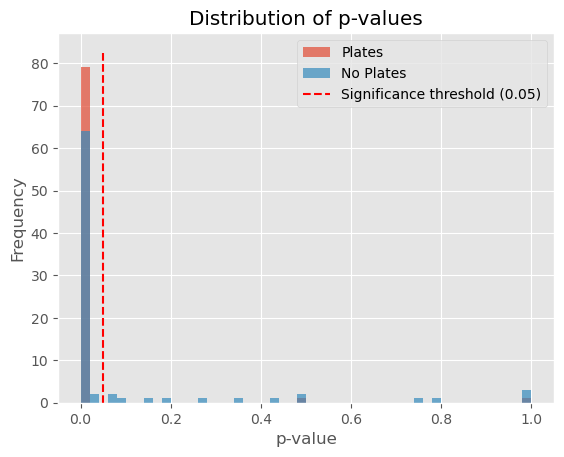

In [186]:
plt.hist(wilcoxon_results_plates['p_value'], bins=50, alpha=0.7, label='Plates')
plt.hist(wilcoxon_results_no['p_value'], bins=50, alpha=0.7, label='No Plates')
plt.vlines(0.05, ymin=0, ymax=plt.gca().get_ylim()[1], colors='red', linestyles='dashed', label='Significance threshold (0.05)')
plt.xlabel('p-value')
plt.ylabel('Frequency')
plt.title('Distribution of p-values')
plt.legend()